Decision tree in python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# Classificazione - dataset wine

In [6]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
print(X_wine[:5])
print(y_wine[:5])

[[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]
 [1.437e+01 1.950e+00 2.500e+00 1.680e+01 1.130e+02 3.850e+00 3.490e+00
  2.400e-01 2.180e+00 7.800e+00 8.600e-01 3.450e+00 1.480e+03]
 [1.324e+01 2.590e+00 2.870e+00 2.100e+01 1.180e+02 2.800e+00 2.690e+00
  3.900e-01 1.820e+00 4.320e+00 1.040e+00 2.930e+00 7.350e+02]]
[0 0 0 0 0]


In [11]:
df_classifier = DecisionTreeClassifier(
    max_depth=3, 
    random_state=42
)

dt_classifier = df_classifier.fit(X_wine, y_wine)
y_pred_class = dt_classifier.predict(X_wine)

In [ ]:
# verifica albero e numero foglie
print(f"DT Depth: {dt_classifier.get_depth()}")
print(f"DT # Leaves: {dt_classifier.get_n_leaves()}")

DT Depth: 3
DT # Leaves: 8


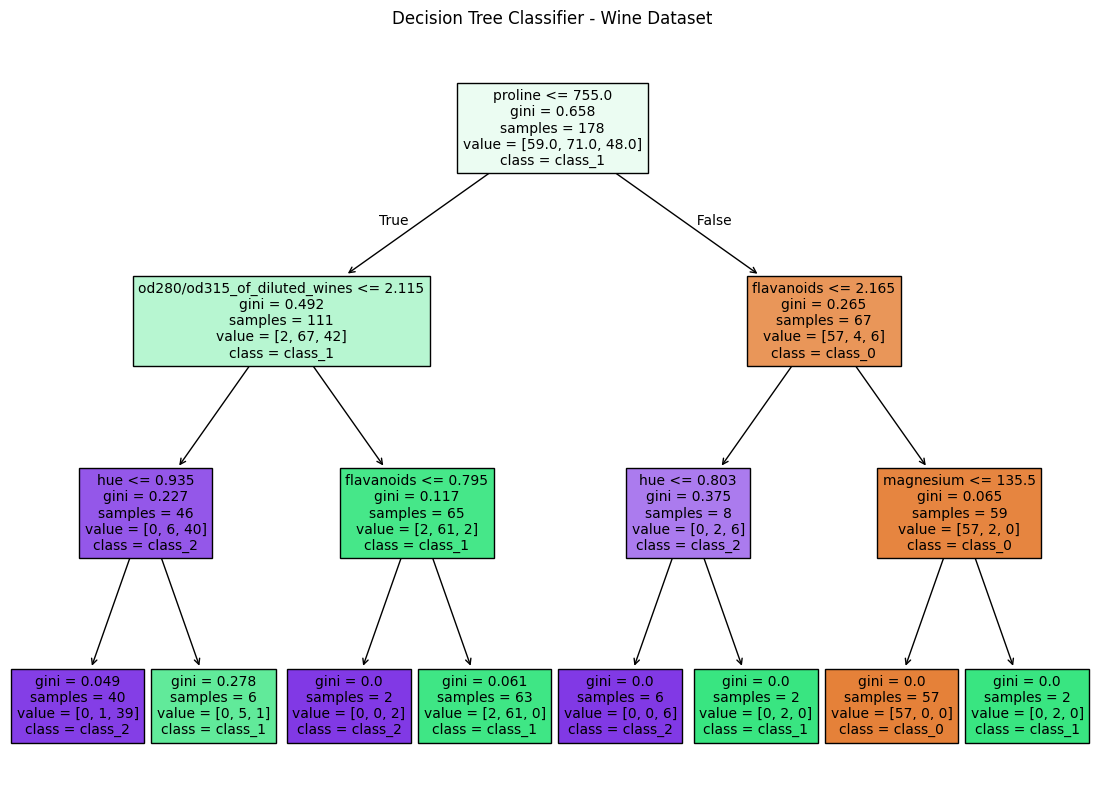

In [10]:
plt.figure(figsize=(14, 10))
plot_tree(
    dt_classifier, 
    feature_names=wine.feature_names, 
    class_names=wine.target_names, 
    filled=True,
    fontsize=10
)
plt.title("Decision Tree Classifier - Wine Dataset")
plt.show()

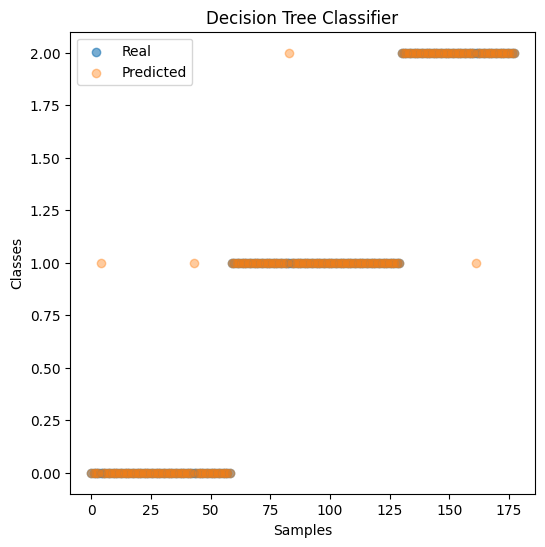

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(range(len(y_wine)), y_wine, label="Real", alpha=0.6)
plt.scatter(range(len(y_wine)), y_pred_class, label="Predicted", alpha=0.4)
plt.title("Decision Tree Classifier")
plt.xlabel("Samples")
plt.ylabel("Classes")
plt.legend()
plt.show()

In [17]:
classification_accuracy = (y_pred_class == y_wine).sum() / len(y_wine)
print(f"Classification Accuracy: {classification_accuracy*100:.2f}%")

Classification Accuracy: 97.75%


Regressione - California Housing

In [18]:
cali = fetch_california_housing()
X_cali = cali.data
y_cali = cali.target

In [19]:
dt_regressor = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)
dt_regressor.fit(X_cali, y_cali)
y_pred_regr = dt_regressor.predict(X_cali)

In [20]:
# verifica albero e numero foglie
print(f"DT Depth: {dt_classifier.get_depth()}")
print(f"DT # Leaves: {dt_classifier.get_n_leaves()}")

DT Depth: 3
DT # Leaves: 8


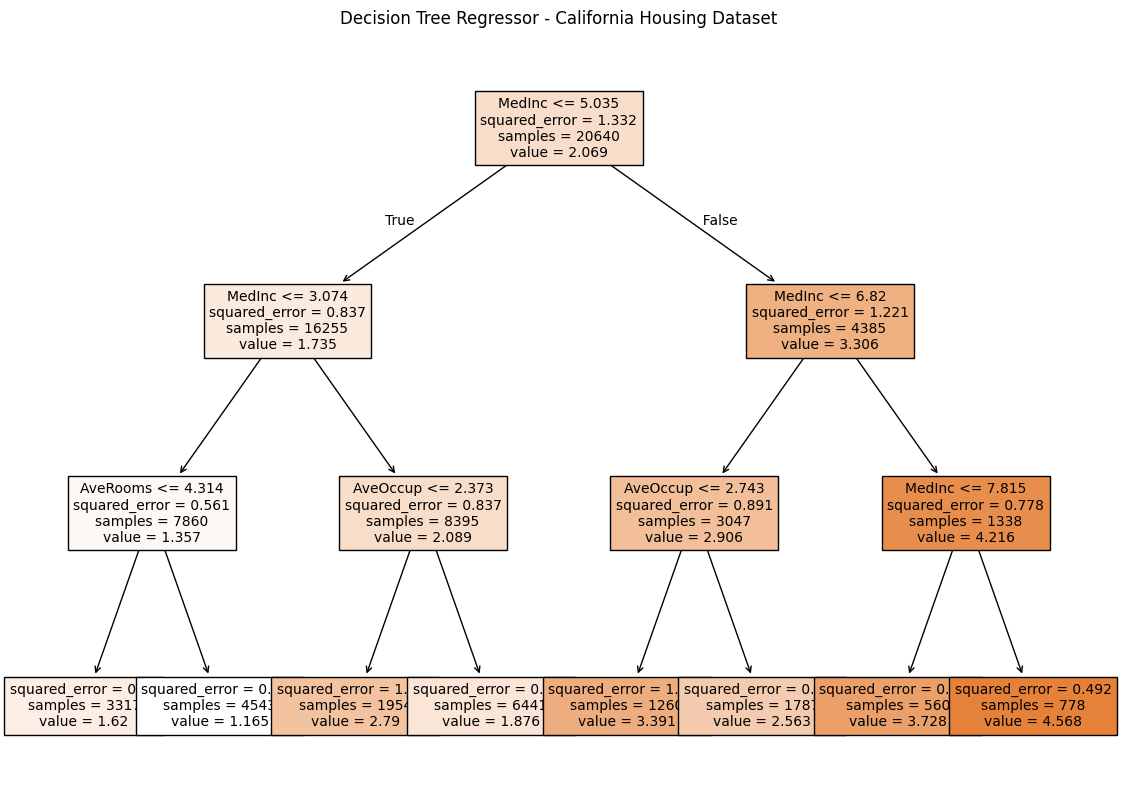

In [21]:
plt.figure(figsize=(14, 10))
plot_tree(
    dt_regressor, 
    feature_names=cali.feature_names, 
    class_names=None, 
    filled=True,
    fontsize=10
)
plt.title("Decision Tree Regressor - California Housing Dataset")
plt.show()

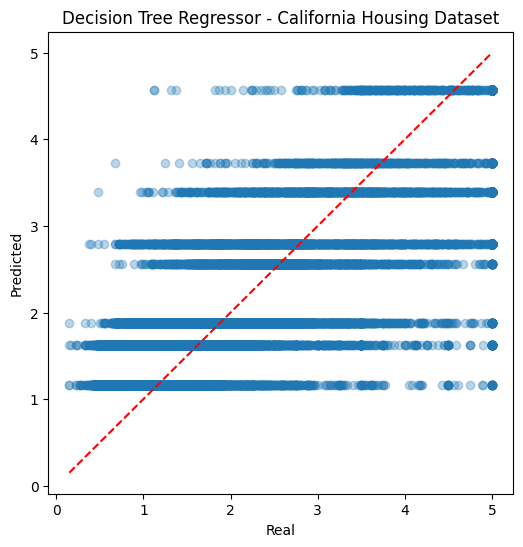

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_cali, y_pred_regr, alpha=0.3)
# serve a fare una linea di riferimento per vedere quanto i punti si discostano da una perfetta predizione
plt.plot([y_cali.min(), y_cali.max()], [y_cali.min(), y_cali.max()], 'r--')
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.title("Decision Tree Regressor - California Housing Dataset")
plt.show()

# i punti sono predetti beni se sono disposti lungo la linea tratteggiata

In [23]:
tols = [0.01, 0.1, 0.5, 1.0]
for tol in tols:
    regr_accuracy = (abs(y_cali - y_pred_regr) < tol).sum() / len(y_cali)
    print(f"Regression Accuracy ({tol}):\t{round(regr_accuracy*100, 2)}%\t{regr_accuracy}")

Regression Accuracy (0.01):	1.31%	0.01308139534883721
Regression Accuracy (0.1):	11.59%	0.11593992248062016
Regression Accuracy (0.5):	54.66%	0.5465600775193798
Regression Accuracy (1.0):	83.63%	0.8362887596899224
